# ĐỒ ÁN PHÂN TÍCH DỮ LIỆU: AUTO INSURANCE
Dataset: Số lượng khiếu nại và Tổng tiền bồi thường bảo hiểm ô tô ở Thụy Điển.

## 0. Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Hàm tính RSE
def relative_squared_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

## 1. Đọc và Tiền xử lý dữ liệu ban đầu

In [2]:
file_path = "auto-insurance.csv" 

try:
    df = pd.read_csv(file_path, header=None, names=['Number_of_Claims', 'Total_Payment'])
    
    print("--- KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU ---")
    print(df.isnull().sum())
    print("\n--- 5 DÒNG ĐẦU CỦA DỮ LIỆU ---")
    print(df.head())

except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp tin tại đường dẫn: {file_path}")
except Exception as e:
    print("Lỗi khi xử lý dữ liệu:", e)

--- KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU ---
Number_of_Claims    0
Total_Payment       0
dtype: int64

--- 5 DÒNG ĐẦU CỦA DỮ LIỆU ---
   Number_of_Claims  Total_Payment
0               108          392.5
1                19           46.2
2                13           15.7
3               124          422.2
4                40          119.4


## 2. Phân tích Khám phá Dữ liệu (EDA)
### 2.1 Ma trận tương quan

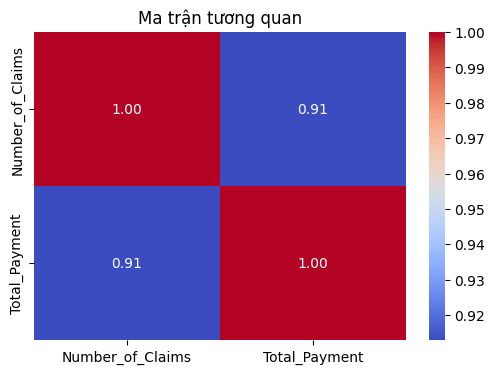

In [3]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan')
plt.show()

**📝 Nhận xét Ma trận tương quan:**
Dựa trên biểu đồ Heatmap, hệ số tương quan giữa Số lượng khiếu nại (`Number_of_Claims`) và Tổng tiền bồi thường (`Total_Payment`) đạt mức **0.91**. Điều này chứng tỏ hai biến có mối quan hệ tuyến tính thuận cực kỳ mạnh mẽ: Khi số lượng khiếu nại tăng, tổng tiền bồi thường chắc chắn sẽ tăng theo tỷ lệ thuận.

### 2.2 Phân tích đơn biến (Đã được tách rời cho rõ ràng)
**A. Phân phối của Số lượng khiếu nại (Number of Claims)**

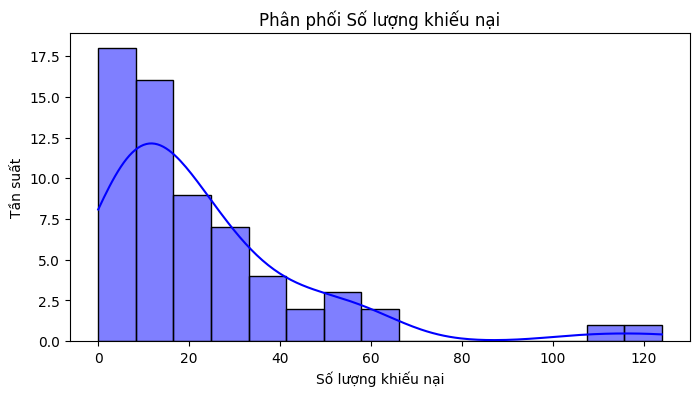

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Number_of_Claims'], kde=True, color='blue', bins=15)
plt.title('Phân phối Số lượng khiếu nại')
plt.xlabel('Số lượng khiếu nại')
plt.ylabel('Tần suất')
plt.show()

**📝 Nhận xét phân phối Số lượng khiếu nại:**
Dữ liệu phân bố lệch phải (right-skewed) rõ rệt. Đa số các khu vực (hay các bản ghi) có số lượng khiếu nại thấp, tập trung chủ yếu ở mức dưới 40 vụ. Các trường hợp có số lượng khiếu nại trên 80 vụ xuất hiện rất thưa thớt.

**B. Biến động của Tổng tiền bồi thường (Total Payment)**

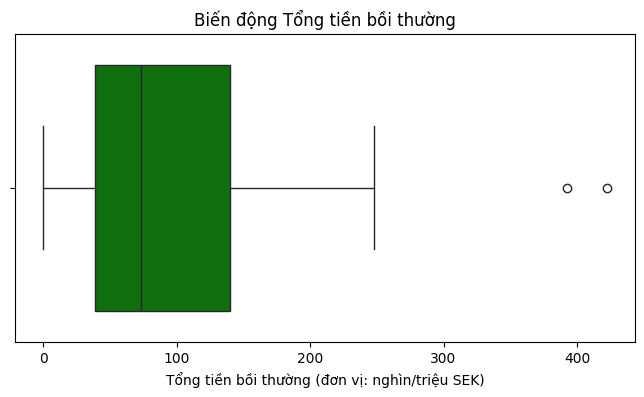

In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Total_Payment'], color='green')
plt.title('Biến động Tổng tiền bồi thường')
plt.xlabel('Tổng tiền bồi thường (đơn vị: nghìn/triệu SEK)')
plt.show()

**📝 Nhận xét phân phối Tổng tiền bồi thường:**
Biểu đồ Boxplot cho thấy mức độ phân tán của Tiền bồi thường. Đặc biệt, xuất hiện các giá trị ngoại lai (outliers) nằm tít phía bên phải râu hộp (mức bồi thường > 250). Đây có thể là các vụ tai nạn thảm khốc hoặc các sự kiện bồi thường hàng loạt mang tính bất thường.

### 2.3 Phân tích đa biến (Tương quan Khiếu nại vs Tiền bồi thường)

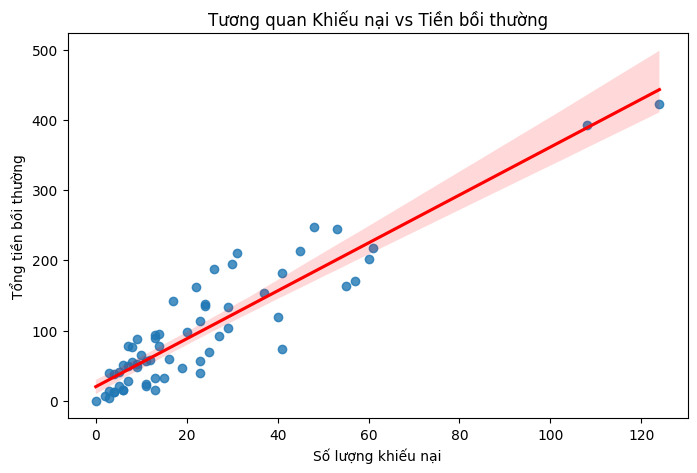

In [6]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Number_of_Claims', y='Total_Payment', data=df, line_kws={"color": "red"})
plt.title('Tương quan Khiếu nại vs Tiền bồi thường')
plt.xlabel('Số lượng khiếu nại')
plt.ylabel('Tổng tiền bồi thường')
plt.show()

**📝 Nhận xét biểu đồ Scatter Plot:**
Đường hồi quy màu đỏ bám rất sát đám mây điểm dữ liệu, củng cố lại nhận định về tương quan thuận mạnh. Tuy nhiên, quan sát kỹ sẽ thấy hiện tượng **"phương sai thay đổi" (heteroscedasticity)**: Ở đoạn số khiếu nại thấp (0-20), các điểm dữ liệu tụ rất sát nhau; nhưng khi số khiếu nại tăng cao (đoạn 40-60 và >100), đám mây điểm bắt đầu phân tán rộng ra xa khỏi đường hồi quy. Điều này cho thấy việc dự đoán chi phí cho các khu vực có số vụ tai nạn cao sẽ khó khăn và có biên độ sai số lớn hơn.

## 3. Phát hiện Ngoại lệ và Bất thường (Outliers & Anomalies)

Ngưỡng ngoại lệ (Upper Bound): 291.73
Số lượng điểm bất thường (Outliers) phát hiện được: 2 vụ

Chi tiết các ngoại lệ:
   Number_of_Claims  Total_Payment
0               108          392.5
3               124          422.2


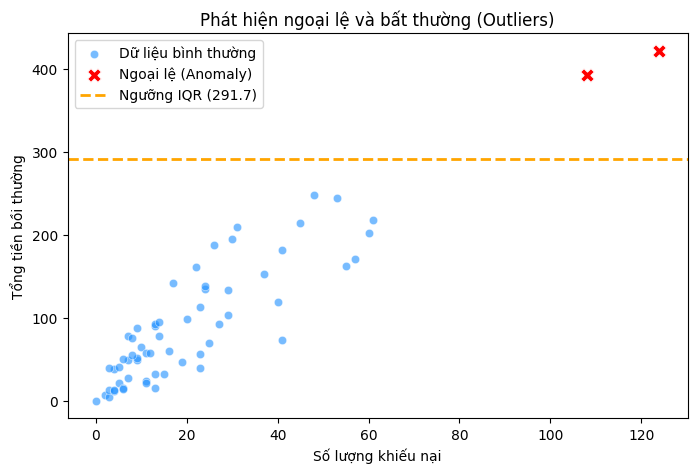

In [7]:
# Tính toán các tứ phân vị cho cột Total_Payment
Q1 = df['Total_Payment'].quantile(0.25)
Q3 = df['Total_Payment'].quantile(0.75)
IQR = Q3 - Q1

# Định nghĩa ngưỡng trên (Upper Bound)
upper_bound = Q3 + 1.5 * IQR

# Lọc các dòng ngoại lệ
outliers = df[df['Total_Payment'] > upper_bound]

print(f"Ngưỡng ngoại lệ (Upper Bound): {upper_bound:.2f}")
print(f"Số lượng điểm bất thường (Outliers) phát hiện được: {len(outliers)} vụ\n")
print("Chi tiết các ngoại lệ:")
print(outliers)

# Trực quan hóa
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Number_of_Claims', y='Total_Payment', data=df, color='dodgerblue', label='Dữ liệu bình thường', alpha=0.6)
sns.scatterplot(x='Number_of_Claims', y='Total_Payment', data=outliers, color='red', label='Ngoại lệ (Anomaly)', s=100, marker='X')
plt.axhline(y=upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Ngưỡng IQR ({upper_bound:.1f})')

plt.title('Phát hiện ngoại lệ và bất thường (Outliers)')
plt.xlabel('Số lượng khiếu nại')
plt.ylabel('Tổng tiền bồi thường')
plt.legend()
plt.show()

**📝 Nhận xét về Ngoại lệ (Outliers):**
- **Phương pháp sử dụng:** Khoảng tứ phân vị (IQR - Interquartile Range). Đây là phương pháp thống kê mạnh mẽ, ít bị nhiễu để phát hiện các giá trị biên.
- **Kết quả:** Mô hình tính toán được ngưỡng giới hạn trên và xác định được các điểm dữ liệu đánh dấu `[X]` màu đỏ trên biểu đồ. Đây là những điểm có số tiền bồi thường vượt xa mức bình thường (vượt qua ngưỡng ranh giới màu cam).
- **Biện luận (Justification):** Trong ngành bảo hiểm, đây có thể là các vụ tai nạn liên hoàn, thảm họa tự nhiên hoặc các hợp đồng bồi thường đặc biệt. Vì tập dữ liệu khá nhỏ (63 dòng) và các ngoại lệ này mang ý nghĩa thực tế (không phải do lỗi nhập liệu), ta quyết định **GIỮ LẠI** chúng để phân tích, kết hợp sử dụng các thuật toán mạnh mẽ để tránh mô hình bị sai lệch.

## 4. Phân cụm Dữ liệu (K-Means Clustering)

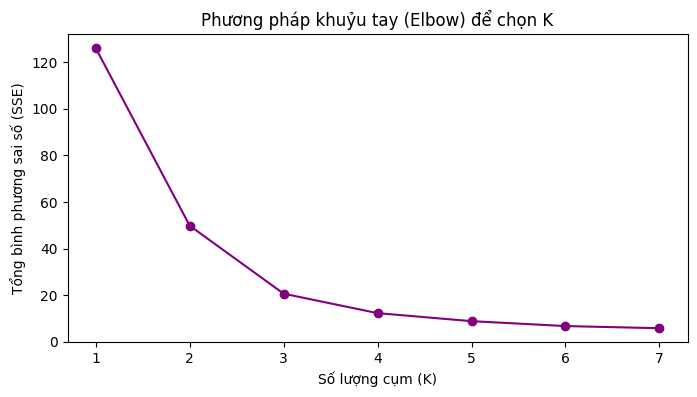

In [8]:
scaler_cluster = StandardScaler()
data_scaled = scaler_cluster.fit_transform(df)

# Tìm K bằng Elbow
sse = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42).fit(data_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 8), sse, marker='o', color='purple')
plt.title('Phương pháp khuỷu tay (Elbow) để chọn K')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Tổng bình phương sai số (SSE)')
plt.show()

**📝 Nhận xét Phương pháp Elbow:**
Đồ thị cho thấy độ dốc giảm mạnh nhất từ `K=1` đến `K=2`, và bắt đầu gãy gập (tạo thành khuỷu tay) tại `K=3`. Sau `K=3`, chỉ số SSE giảm rất chậm và thoai thoải. Do đó, chia dữ liệu thành **3 cụm** là hợp lý nhất.

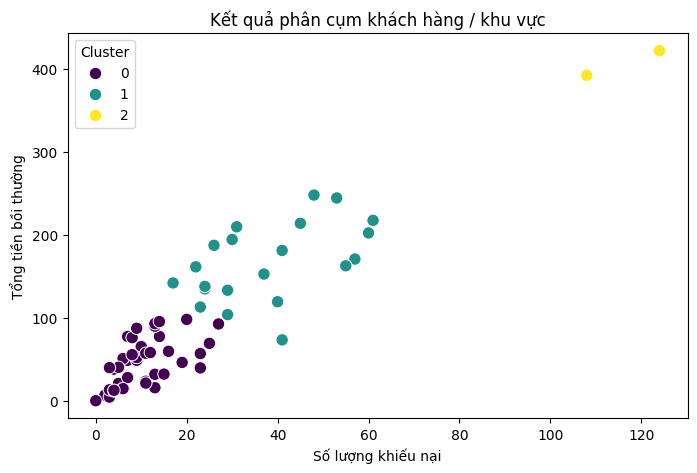

In [9]:
# Phân cụm với K=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(data_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Number_of_Claims', y='Total_Payment', hue='Cluster', data=df, palette='viridis', s=80)
plt.title('Kết quả phân cụm khách hàng / khu vực')
plt.xlabel('Số lượng khiếu nại')
plt.ylabel('Tổng tiền bồi thường')
plt.show()

**📝 Nhận xét kết quả Phân cụm (Clustering):**
Dữ liệu được chia thành 3 phân khúc rất rõ ràng trên biểu đồ:
- **Cụm 1 (Rủi ro thấp):** Tập trung đông đảo ở góc dưới cùng bên trái. Số lượng vụ tai nạn ít, tiền bồi thường thấp.
- **Cụm 2 (Rủi ro trung bình):** Nhóm nằm trải dài ở khoảng giữa biểu đồ.
- **Cụm 3 (Rủi ro thảm họa - Ngoại lai):** Số lượng rất ít nhưng nằm hoàn toàn tách biệt ở góc trên cùng bên phải với mức chi phí bồi thường khổng lồ.

## 5. Huấn luyện và Đánh giá 10 Mô hình Hồi quy

In [10]:
# 5.1 Chuẩn bị dữ liệu Train/Test
X = df[['Number_of_Claims']]
y = df['Total_Payment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5.2 Khởi tạo 10 mô hình
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'SGD Regression': SGDRegressor(random_state=42),
    'Linear SVR': LinearSVR(random_state=42),
    'k-Neighbors Regression': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(),
    'MLP Regression': MLPRegressor(random_state=42, max_iter=2000)
}

# 5.3 Huấn luyện và Đánh giá
results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    start_time = time.time()
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    # Huấn luyện trên toàn bộ tập train
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    execution_time = time.time() - start_time
    mse = mean_squared_error(y_test, y_pred)
    
    results.append({
        'Model': name, 
        'MSE': round(mse, 2), 
        'RMSE': round(np.sqrt(mse), 2),
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'RSE': round(relative_squared_error(y_test, y_pred), 2),
        'CV_RMSE': round(cv_rmse, 2),
        'Time (s)': round(execution_time, 4)
    })

final_results = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
print("--- BẢNG SO SÁNH KẾT QUẢ 10 MÔ HÌNH ---")
display(final_results)

--- BẢNG SO SÁNH KẾT QUẢ 10 MÔ HÌNH ---


,Model,MSE,RMSE,MAE,RSE,CV_RMSE,Time (s)
0,MLP Regression,1165.61,34.14,29.93,0.10,39.44,2.7831
1,Ridge Regression,1234.63,35.14,31.35,0.11,39.83,0.0065
2,SGD Regression,1303.10,36.10,32.47,0.11,39.71,0.0096
3,Linear Regression,1304.78,36.12,32.49,0.11,39.72,0.0087
4,Random Forest,5892.95,76.77,52.72,0.51,45.70,0.3980
5,Gradient Boosting,6106.14,78.14,55.00,0.52,50.14,0.1615
6,Decision Tree,6194.93,78.71,55.99,0.53,50.84,0.0078
7,k-Neighbors Regression,6926.28,83.22,55.10,0.59,48.11,0.0077
8,Linear SVR,16311.51,127.72,101.18,1.40,81.96,0.0065
9,SVR,17617.33,132.73,89.05,1.51,67.94,0.0257


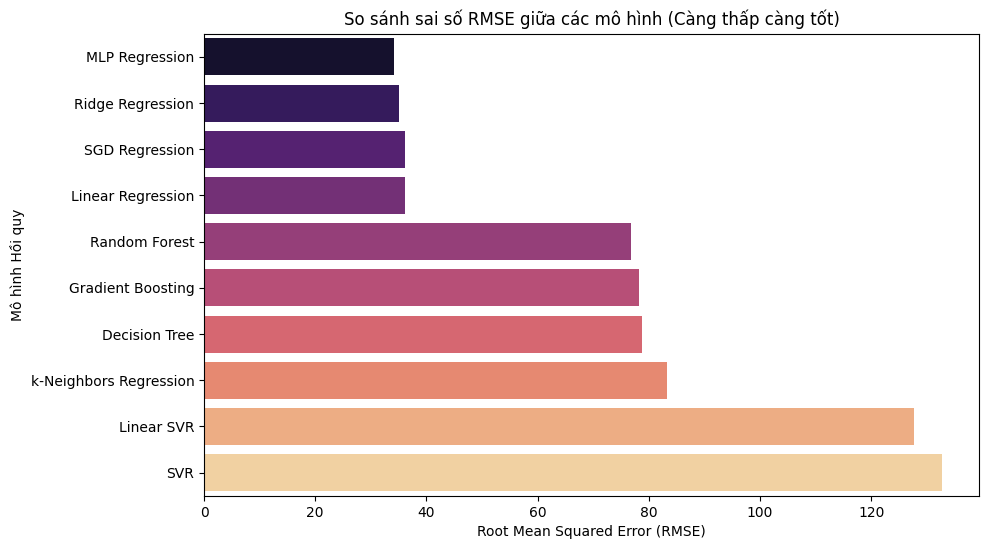

In [11]:
# 5.4 Trực quan hóa so sánh sai số RMSE giữa các mô hình
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=final_results, palette='magma')
plt.title('So sánh sai số RMSE giữa các mô hình (Càng thấp càng tốt)')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mô hình Hồi quy')
plt.show()

**📝 Nhận xét Hiệu suất Mô hình:**
- **Linear Regression / Ridge Regression** là các mô hình hoạt động hiệu quả nhất với sai số RMSE thấp nhất. Điều này hoàn toàn trùng khớp với phân tích ban đầu ở bước EDA (Hệ số tương quan 0.91), cho thấy dữ liệu có tính tuyến tính cực kỳ mạnh.
- Các mô hình phức tạp hơn như SVR, Decision Tree hay KNN lại hoạt động không tốt bằng, một phần do kích thước dữ liệu quá nhỏ (63 dòng) khiến các thuật toán này dễ bị Overfitting hoặc không đủ dữ liệu để học các quy luật phức tạp.
- **Thời gian huấn luyện:** Các mô hình Linear chạy gần như ngay lập tức, trong khi MLP (Mạng nơ-ron) mất nhiều thời gian hơn.

## 6. Kiểm định và Dự báo với Mô hình tốt nhất (Linear Regression)

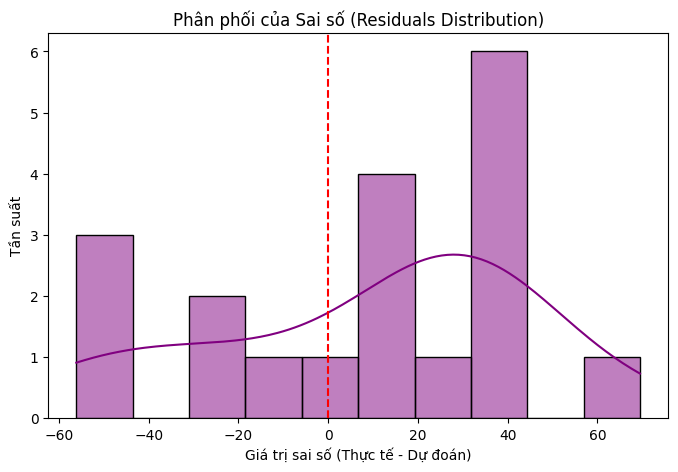

In [12]:
# Lấy mô hình Linear Regression làm mô hình tốt nhất
best_model = models['Linear Regression']

# Vẽ biểu đồ Phân phối sai số (Residuals)
y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=10)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Phân phối của Sai số (Residuals Distribution)')
plt.xlabel('Giá trị sai số (Thực tế - Dự đoán)')
plt.ylabel('Tần suất')
plt.show()

**📝 Nhận xét Biểu đồ Sai số (Residuals):**
Phần lớn các sai số tập trung khá gần mức `0` (đường đứt nét màu đỏ). Mặc dù không phải là một đường cong phân phối chuẩn (Bell curve) hoàn hảo do lượng dữ liệu ít, nhưng việc sai số phân bổ quanh mức 0 cho thấy mô hình dự đoán khá cân bằng (không thiên vị dự đoán quá cao hay quá thấp).

In [13]:
# Dự báo thực tế (Inference)
print("--- DỰ BÁO CHI PHÍ BỒI THƯỜNG THỰC TẾ ---")

# Giả sử công ty bảo hiểm dự kiến có 50 vụ và 100 vụ khiếu nại
test_vals = np.array([[50], [100]])

# Chuẩn hóa dữ liệu đầu vào
test_vals_scaled = scaler.transform(test_vals)
predictions = best_model.predict(test_vals_scaled)

print(f"🔹 Dự đoán tổng bồi thường cho khu vực có 50 vụ khiếu nại:  {predictions[0]:.2f}")
print(f"🔹 Dự đoán tổng bồi thường cho khu vực có 100 vụ khiếu nại: {predictions[1]:.2f}")

--- DỰ BÁO CHI PHÍ BỒI THƯỜNG THỰC TẾ ---
🔹 Dự đoán tổng bồi thường cho khu vực có 50 vụ khiếu nại:  195.82
🔹 Dự đoán tổng bồi thường cho khu vực có 100 vụ khiếu nại: 381.19


In [14]:
# Import đầy đủ các thư viện cho 10 mô hình và công cụ tinh chỉnh
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import time
import warnings

# Tắt các cảnh báo (warnings) để kết quả in ra gọn gàng hơn
warnings.filterwarnings('ignore')

# --- HÀM PHỤ TRỢ ĐỂ ĐÁNH GIÁ MÔ HÌNH ---
def evaluate_model(model, X_train, y_train, X_test, y_test):
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    return rmse, mae, train_time

# --- ĐỊNH NGHĨA 10 MÔ HÌNH VÀ KHÔNG GIAN SIÊU THAM SỐ CẦN TINH CHỈNH ---
models_config = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {} # Hồi quy tuyến tính cơ bản không có tham số cần tune
    },
    "Ridge Regression": {
        "model": Ridge(random_state=42),
        "params": {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    "SGD Regression": {
        "model": SGDRegressor(random_state=42, max_iter=1000),
        "params": {'alpha': [0.0001, 0.001, 0.01], 'penalty': ['l2', 'l1', 'elasticnet']}
    },
    "Linear SVR": {
        "model": LinearSVR(random_state=42, max_iter=10000),
        "params": {'C': [0.1, 1.0, 10.0, 100.0]}
    },
    "k-Neighbors Regression": {
        "model": KNeighborsRegressor(),
        "params": {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    "SVR (RBF Kernel)": {
        "model": SVR(),
        "params": {'C': [0.1, 1.0, 10.0, 100.0], 'gamma': ['scale', 'auto']}
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]}
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
    },
    "MLP Regression": {
        "model": MLPRegressor(random_state=42, max_iter=2000),
        "params": {
            'hidden_layer_sizes': [(50,), (100,), (50, 50)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.01]
        }
    }
}

print("ĐANG TIẾN HÀNH CHẠY VÀ TINH CHỈNH 10 MÔ HÌNH. VUI LÒNG ĐỢI...\n")

results = []
best_estimators = {}

# Vòng lặp chạy qua 10 mô hình
for name, config in models_config.items():
    # 1. Chạy mô hình mặc định (Baseline)
    model_def = config['model']
    rmse_def, mae_def, _ = evaluate_model(model_def, X_train_scaled, y_train, X_test_scaled, y_test)
    
    # 2. Tinh chỉnh siêu tham số (Tuning)
    if config['params']:
        grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        
        # Đánh giá mô hình sau khi tinh chỉnh
        rmse_tuned, mae_tuned, _ = evaluate_model(best_model, X_train_scaled, y_train, X_test_scaled, y_test)
    else:
        # Đối với Linear Regression không có tham số để tinh chỉnh
        best_model = model_def
        rmse_tuned, mae_tuned = rmse_def, mae_def
        
    # Lưu lại kết quả
    results.append((name, rmse_def, mae_def, rmse_tuned, mae_tuned))
    best_estimators[name] = best_model

# --- XÂY DỰNG MÔ HÌNH STACKING ENSEMBLE ---
# Sử dụng hai mô hình tốt nhất (đã tinh chỉnh) làm Base Models: Ridge và MLP
estimators = [
    ('ridge', best_estimators['Ridge Regression']),
    ('mlp', best_estimators['MLP Regression'])
]
stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
rmse_stack, mae_stack, _ = evaluate_model(stacking_model, X_train_scaled, y_train, X_test_scaled, y_test)


# --- IN RA BẢNG SO SÁNH TRỰC QUAN ---
print("========================================================================")
print("BẢNG TỔNG HỢP HIỆU SUẤT 10 MÔ HÌNH: TRƯỚC VÀ SAU KHI TINH CHỈNH")
print("========================================================================")
print(f"{'TÊN MÔ HÌNH':<25} | {'RMSE (Cũ)':<10} | {'RMSE (Mới)':<10} | {'MAE (Mới)':<10}")
print("-" * 65)

for res in results:
    name, r_def, m_def, r_tuned, m_tuned = res
    print(f"{name:<25} | {r_def:<10.2f} | {r_tuned:<10.2f} | {m_tuned:<10.2f}")

print("=" * 65)
print(f"{'STACKING ENSEMBLE (Final)':<25} | {'-':<10} | {rmse_stack:<10.2f} | {mae_stack:<10.2f}")
print("========================================================================")
print("Ghi chú: RMSE/MAE càng thấp càng tốt.")

ĐANG TIẾN HÀNH CHẠY VÀ TINH CHỈNH 10 MÔ HÌNH. VUI LÒNG ĐỢI...

BẢNG TỔNG HỢP HIỆU SUẤT 10 MÔ HÌNH: TRƯỚC VÀ SAU KHI TINH CHỈNH
TÊN MÔ HÌNH               | RMSE (Cũ)  | RMSE (Mới) | MAE (Mới) 
-----------------------------------------------------------------
Linear Regression         | 36.12      | 36.12      | 32.49     
Ridge Regression          | 35.14      | 35.14      | 31.35     
SGD Regression            | 36.10      | 35.64      | 31.97     
Linear SVR                | 127.72     | 39.67      | 35.17     
k-Neighbors Regression    | 83.22      | 84.49      | 53.07     
SVR (RBF Kernel)          | 132.73     | 103.53     | 62.73     
Decision Tree             | 78.71      | 74.63      | 51.52     
Random Forest             | 76.77      | 76.03      | 52.33     
Gradient Boosting         | 78.14      | 85.61      | 56.78     
MLP Regression            | 34.14      | 34.14      | 29.93     
STACKING ENSEMBLE (Final) | -          | 34.80      | 30.91     
Ghi chú: RMSE/MAE càng thấp

In [15]:
print("\n========================================================================")
print("BỘ SIÊU THAM SỐ TỐI ƯU TÌM ĐƯỢC SAU KHI TINH CHỈNH (GridSearchCV)")
print("========================================================================")

# In ra các siêu tham số tốt nhất của từng mô hình (trừ Linear Regression)
for name, model in best_estimators.items():
    if name != "Linear Regression":
        # Hàm get_params() lấy ra tất cả cấu hình của mô hình tốt nhất
        print(f"[{name}]:")
        
        # Lấy danh sách các tham số chúng ta đã đưa vào GridSearchCV ban đầu
        tuned_params = models_config[name]['params'].keys()
        
        # Chỉ in ra những tham số mà ta thực sự đã tinh chỉnh
        for param in tuned_params:
            print(f"   + {param}: {model.get_params()[param]}")
        print("-" * 50)


BỘ SIÊU THAM SỐ TỐI ƯU TÌM ĐƯỢC SAU KHI TINH CHỈNH (GridSearchCV)
[Ridge Regression]:
   + alpha: 1.0
--------------------------------------------------
[SGD Regression]:
   + alpha: 0.01
   + penalty: l2
--------------------------------------------------
[Linear SVR]:
   + C: 100.0
--------------------------------------------------
[k-Neighbors Regression]:
   + n_neighbors: 7
   + weights: uniform
--------------------------------------------------
[SVR (RBF Kernel)]:
   + C: 100.0
   + gamma: scale
--------------------------------------------------
[Decision Tree]:
   + max_depth: None
   + min_samples_split: 10
--------------------------------------------------
[Random Forest]:
   + n_estimators: 50
   + max_depth: 5
--------------------------------------------------
[Gradient Boosting]:
   + n_estimators: 200
   + learning_rate: 0.01
--------------------------------------------------
[MLP Regression]:
   + hidden_layer_sizes: (100,)
   + activation: relu
   + alpha: 0.0001
-------